In [1]:
#!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys
import os

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import numerical_utils as nuti

#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF
import update_config as uc
#local utils.py
import utils as U 



# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Extra for analysis and 'loggy' levels
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors


# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers
import importlib
from pathlib import Path

# Constants
grav=Co.grav()
cp=Co.cpair()

importlib.reload(U)


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


<module 'utils' from '/glade/work/juliob/HiRes_ana_dev/Drivers/Analysis/utils.py'>

In [2]:
%%time
year,month=2004,8 #2004,7
date_tag = f"{year:04}-{month:02}-*"


#f=f'/glade/derecho/scratch/juliob/archive/test_fgf/atm/regridded/test_fgf.cam.h2i.1985-07-01-00000.nc'
#f=f'/glade/derecho/scratch/juliob/archive/test_fgf/atm/regridded/test_fgf.cam.h2i.1985-01-15-00000.nc'

f=f'/glade/derecho/scratch/juliob/archive/GW_UnitTest/xy-rdg-mm-frnt-00/xy-rdg-mm-frnt-00.h.{date_tag}.nc'
ncdata=f'/glade/derecho/scratch/juliob/archive//c153_topfix_ne240pg3_FMTHIST_xic_x02/atm/fv1x1/c153_topfix_ne240pg3_FMTHIST_xic_x02.cam.h1i.{date_tag}.nc' 


#ncdata='/glade/derecho/scratch/juliob/archive/test_fgf/atm/regridded/test_fgf.cam.h2i.1985-07-15-00000.nc'
#f='/glade/derecho/scratch/juliob/archive/GW_UnitTest/xy-frontal-04/xy-frontal-04.h.1985-07-15-00000.nc'
 


print( f )
X=xr.open_mfdataset( f ,data_vars='different', coords='different' , compat='no_conflicts' )
Xnc=xr.open_mfdataset( ncdata ,data_vars='different', coords='different' , compat='no_conflicts' )

/glade/derecho/scratch/juliob/archive/GW_UnitTest/xy-rdg-mm-frnt-00/xy-rdg-mm-frnt-00.h.2004-08-*.nc
CPU times: user 4.92 s, sys: 1.41 s, total: 6.32 s
Wall time: 48.1 s


In [3]:
ny = X.sizes["ny"]
nx = X.sizes["nx"]

j = np.arange(ny).repeat(nx)
i = np.tile(np.arange(nx), ny)

X2 = (
    X.assign_coords(_j=("ncol", j), _i=("ncol", i))     # mapping ncol -> (j,i)
     .set_index(ncol=("_j", "_i"))
     .unstack("ncol")
     .rename({"_j": "ny", "_i": "nx"})
     .assign_coords(ny=X["lat_R"], nx=X["lon_R"])        # put real coords on axes
)


X2['lat']=X['lat_R']
X2['lon']=X['lon_R']
X=X2

In [4]:
X

<xarray.Dataset> Size: 2GB
Dimensions:          (ny: 192, nx: 288, level: 93, ilevel: 94, time: 4)
Coordinates:
  * ny               (ny) float64 2kB -89.76 -89.06 -88.12 ... 88.12 89.06 89.76
  * nx               (nx) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * time             (time) float64 32B 2.004e+07 2.004e+07 2.004e+07 2.004e+07
Dimensions without coordinates: level, ilevel
Data variables: (12/47)
    lat_R            (ny) float64 2kB dask.array<chunksize=(192,), meta=np.ndarray>
    lon_R            (nx) float64 2kB dask.array<chunksize=(288,), meta=np.ndarray>
    hyam             (level) float32 372B dask.array<chunksize=(93,), meta=np.ndarray>
    hybm             (level) float32 372B dask.array<chunksize=(93,), meta=np.ndarray>
    hyai             (ilevel) float32 376B dask.array<chunksize=(94,), meta=np.ndarray>
    hybi             (ilevel) float32 376B dask.array<chunksize=(94,), meta=np.ndarray>
    ...               ...
    TAUN_MM          (time, ilevel, ny, nx) float32 83MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
    TAUS_MM          (time, ilevel, ny, nx) float32 83MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
    TAUE             (time, ilevel, ny, nx) float32 83MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
    TAUW             (time, ilevel, ny, nx) float32 83MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
    TAUN             (time, ilevel, ny, nx) float32 83MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
    TAUS             (time, ilevel, ny, nx) float32 83MB dask.array<chunksize=(1, 47, 96, 288), meta=np.ndarray>
Attributes:
    ncdata:            /glade/derecho/scratch/juliob/archive//c153_topfix_ne2...
    calculation_type:  xy
    Conventions:       CF-1.8

In [5]:
Xnc

<xarray.Dataset> Size: 46GB
Dimensions:      (time: 124, nbnd: 2, ilev: 94, lev: 93, lat: 192, lon: 288)
Coordinates:
  * time         (time) object 992B 2004-08-01 00:00:00 ... 2004-08-31 18:00:00
  * nbnd         (nbnd) int64 16B 0 1
  * ilev         (ilev) float64 752B 0.004259 0.01201 0.02467 ... 995.1 1e+03
  * lev          (lev) float64 744B 0.008135 0.01834 0.03482 ... 991.2 997.5
  * lat          (lat) float64 2kB -89.76 -89.06 -88.12 ... 88.12 89.06 89.76
  * lon          (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
Data variables: (12/16)
    time_bounds  (time, nbnd) object 2kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    hyai         (ilev) float64 752B dask.array<chunksize=(94,), meta=np.ndarray>
    hybi         (ilev) float64 752B dask.array<chunksize=(94,), meta=np.ndarray>
    hyam         (lev) float64 744B dask.array<chunksize=(93,), meta=np.ndarray>
    hybm         (lev) float64 744B dask.array<chunksize=(93,), meta=np.ndarray>
    RhoProxy     (lev) float64 744B dask.array<chunksize=(93,), meta=np.ndarray>
    ...           ...
    tp2          (time, lev, lat, lon) float64 5GB dask.array<chunksize=(1, 93, 192, 288), meta=np.ndarray>
    PS           (time, lat, lon) float64 55MB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    U            (time, lev, lat, lon) float64 5GB dask.array<chunksize=(1, 93, 192, 288), meta=np.ndarray>
    V            (time, lev, lat, lon) float64 5GB dask.array<chunksize=(1, 93, 192, 288), meta=np.ndarray>
    OMEGA        (time, lev, lat, lon) float64 5GB dask.array<chunksize=(1, 93, 192, 288), meta=np.ndarray>
    T            (time, lev, lat, lon) float64 5GB dask.array<chunksize=(1, 93, 192, 288), meta=np.ndarray>

In [6]:


lon=X.lon.values
lat=X.lat.values

Lon,Lat=np.meshgrid(lon,lat)


ftopo='/glade/work/juliob/Topo/NCARTopoJTB/cases/fv1x1_Sco100_GrnlAnt/output/fv1x1_gmted2010_modis_bedmachine_nc3000_Laplace0100_noleak_greenlndantarcsgh30fac2.50_20251009.nc'
Topo=xr.open_dataset( ftopo )

hs = Topo.PHIS.values/grav
sgh = Topo.SGH.values
sgh30 = Topo.SGH30.values

In [7]:
mask= sgh < 10

In [8]:
%%time

te=X.T.values 
u=X.U.values
v=X.V.values

CPU times: user 84.7 ms, sys: 422 ms, total: 506 ms
Wall time: 3.1 s


In [9]:
%%time

tauw_mm=X.TAUW_MM.values 
taue_mm=X.TAUE_MM.values
tauw_fr=X.TAUW.values 
taue_fr=X.TAUE.values


CPU times: user 94.8 ms, sys: 557 ms, total: 652 ms
Wall time: 5.48 s


In [10]:
taus_fr=X.TAUS.values 
taun_fr=X.TAUN.values


In [11]:
%%time
tau_mm=X.TAU_MOVMTN.values 

CPU times: user 31 ms, sys: 118 ms, total: 149 ms
Wall time: 842 ms


In [ ]:
upwp = Xnc.upwp.values
vpwp = Xnc.vpwp.values

In [14]:
tauew_fr = np.abs(tauw_fr) + np.abs(taue_fr) 
tauew_mm = np.abs(tauw_mm) + np.abs(taue_mm) 


In [15]:
epwp = np.sqrt( upwp**2 + vpwp**2 )
tau_fr = np.sqrt( (tauw_fr+taue_fr)**2 + (taun_fr+taus_fr)**2 )

In [16]:
#plev=X.lev.values
plev=100_000. * (X.hyam.values+X.hybm.values)
zlev=-7_000. * np.log( plev / 100_000. )

[1.0e-06 2.0e-06 5.0e-06 1.0e-05 1.5e-05 2.0e-05 3.0e-05 4.0e-05 5.0e-05
 6.0e-05 8.0e-05 1.0e-04 1.5e-04 2.0e-04 3.0e-04 4.0e-04 5.0e-04 6.0e-04
 1.0e-03 1.5e-03 2.0e-03 3.0e-03 4.0e-03 5.0e-03 6.0e-03 1.0e-02 1.5e-02
 2.0e-02 3.0e-02 4.0e-02 5.0e-02 6.0e-02]
25906.918


Text(0.5, 0.98, 'UnitTest vs. ne240: 2004-08, Z=26 km ')

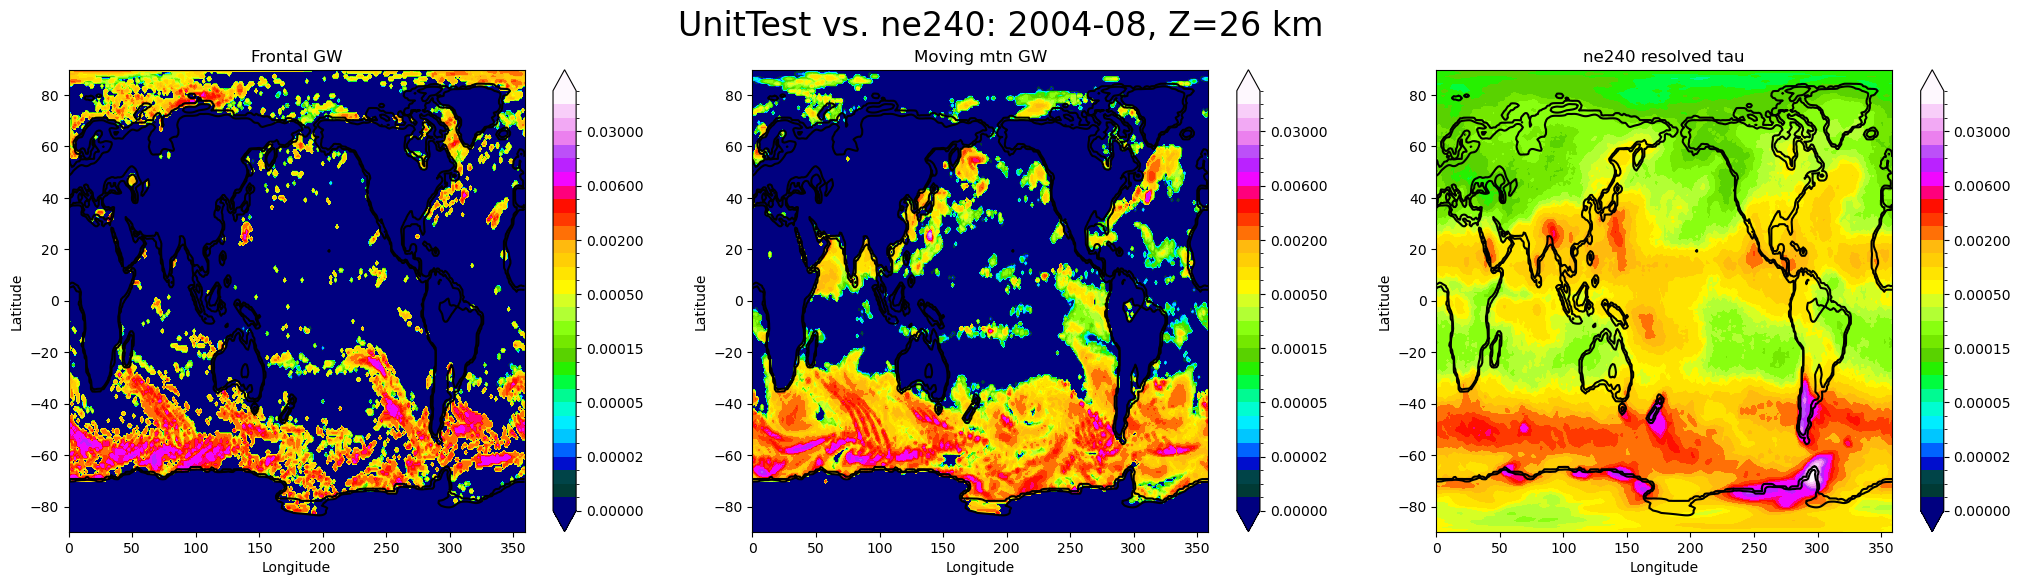

In [17]:
flev=0.01*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='gist_ncar'
wavlev=26
case="UnitTest vs. ne240"
title=f'{case}: {year:04}-{month:02}, Z={zlev[wavlev]/1000.:.0f} km '     #        camsnap-yaaaa.h.2004-06-15-21600.nc'

print( zlev[wavlev] )
cmap = plt.cm.gist_ncar #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)
fig,axs=plt.subplots( 1, 3, figsize=(25,6) )
p=0
ax=axs[p]
c=ax.contourf( lon,lat, np.average(tau_fr,axis=0)[wavlev,:,:]*mask , levels=flev, cmap=cmap, norm=norm, extend='both'  ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_xlabel( "Longitude" )
ax.set_ylabel( "Latitude" )
ax.set_title( "Frontal GW")
plt.colorbar(c)

p=1
ax=axs[p]
c=ax.contourf( lon,lat, np.average(tau_mm,axis=0)[wavlev,:,:] *mask, levels=flev, cmap=cmap, norm=norm, extend='both' ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_xlabel( "Longitude" )
ax.set_ylabel( "Latitude" )
ax.set_title( "Moving mtn GW")
plt.colorbar(c)


p=2
ax=axs[p]
c=ax.contourf( lon,lat, np.average( epwp ,axis=0)[wavlev,:,:] , levels=flev, cmap=cmap, norm=norm, extend='both' ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_xlabel( "Longitude" )
ax.set_ylabel( "Latitude" )
ax.set_title( "ne240 resolved tau")
plt.colorbar(c)
plt.suptitle( title , fontsize=24)

#plt.contourf( np.average(-tauw_fr,axis=0)[20,:,:] )

(10000.0, 85000.0)

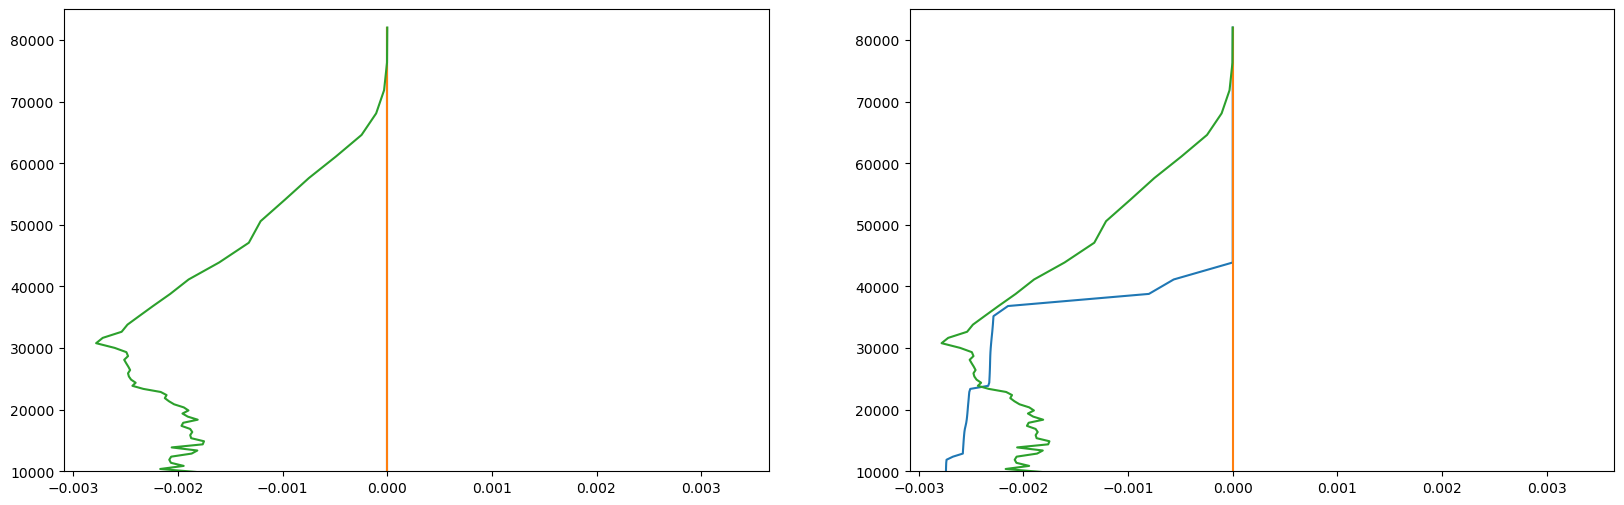

In [18]:
y,x=40,50
#y,x=60,70

fig,axs=plt.subplots(1,2 , figsize=(20,6) )

p=0
ax=axs[p]
ax.plot( np.average(tauw_fr,axis=0)[1:,y,x], zlev )
ax.plot( np.average(taue_fr,axis=0)[1:,y,x], zlev )
ax.plot( np.average(upwp,axis=0)[0:,y,x], zlev )
ax.set_ylim(10000,85000)
p=1
ax=axs[p]
ax.plot( np.average(tauw_mm,axis=0)[1:,y,x], zlev )
ax.plot( np.average(taue_mm,axis=0)[1:,y,x], zlev )
ax.plot( np.average(upwp,axis=0)[0:,y,x], zlev )
ax.set_ylim(10000,85000)


In [19]:
%%time

fgf =X.FRONTGF.values
#th = X.TH.values
#fgf_nc =Xnc.FRONTGF.values

pmid=X.PMID.values

CPU times: user 71.4 ms, sys: 210 ms, total: 282 ms
Wall time: 2.44 s


[1.0e-03 2.0e-03 5.0e-03 1.0e-02 1.5e-02 2.0e-02 3.0e-02 4.0e-02 5.0e-02
 6.0e-02 8.0e-02 1.0e-01 1.5e-01 2.0e-01 3.0e-01 4.0e-01 5.0e-01 6.0e-01
 1.0e+00 1.5e+00 2.0e+00 3.0e+00 4.0e+00 5.0e+00 6.0e+00 1.0e+01 1.5e+01
 2.0e+01 3.0e+01 4.0e+01 5.0e+01 6.0e+01]


NameError: name 'fgf_nc' is not defined

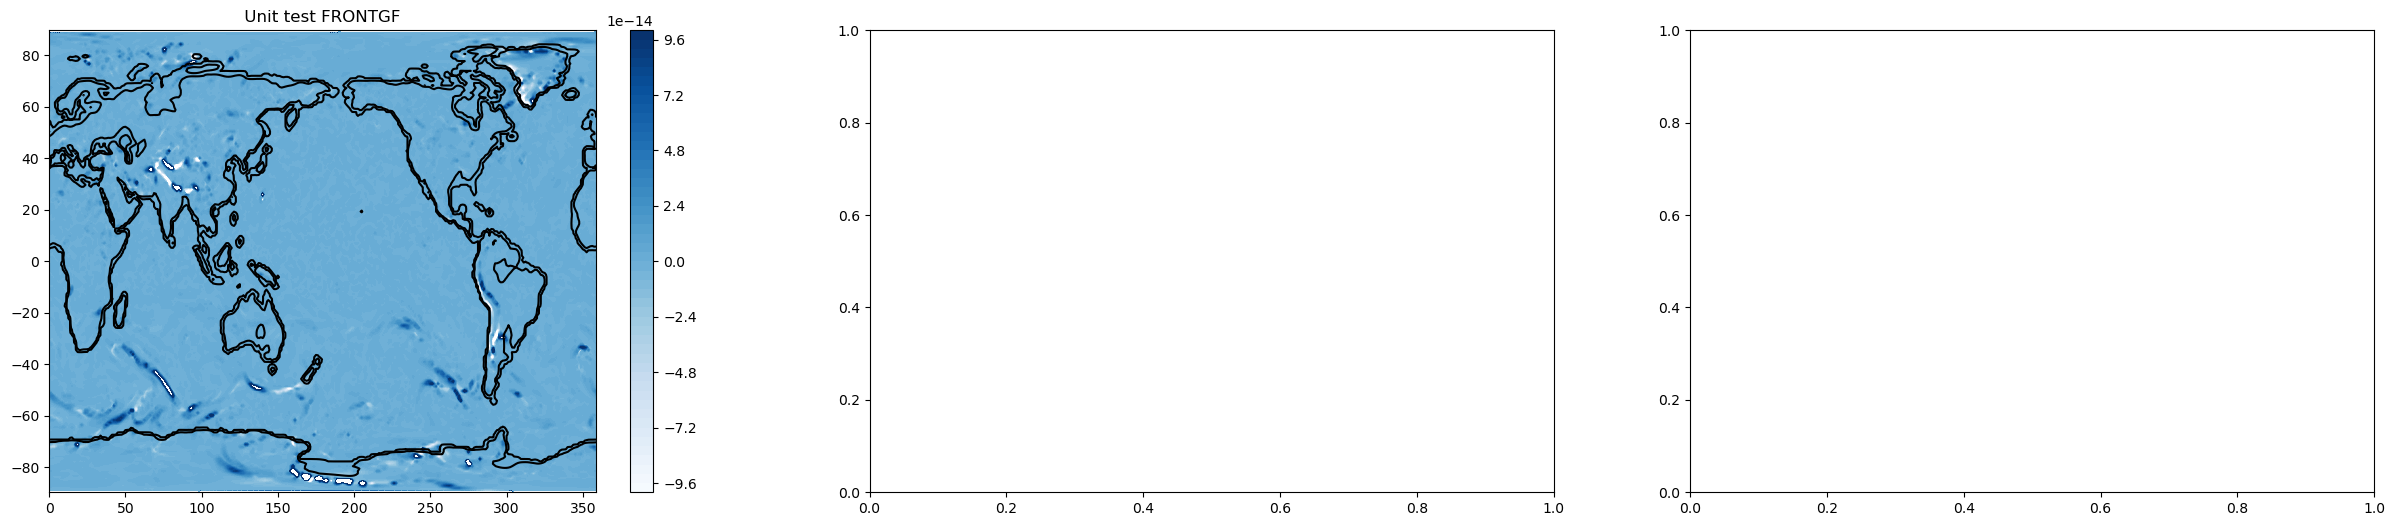

In [20]:
wavlev=40
srclev=70
t=0

flev=10.*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='plasma' #'gist_ncar'


cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )

ax=axs[0]
#c=ax.contourf( lon,lat, grd2se[15,srclev,:,:] , levels=np.linspace(0.,0.01,num=51), cmap=cmap) #levels=51)
c=ax.contourf( lon,lat, fgf[t,srclev,:,:] , levels=1.e-13*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_title(" Unit test FRONTGF ")
plt.colorbar(c)

ax=axs[1]
c=ax.contourf( lon,lat, fgf_nc[t,srclev,:,:] , levels=1.e-13*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_title(" ncdata FRONTGF ")
plt.colorbar(c)

ax=axs[2]
c=ax.contourf( lon,lat, (fgf_nc-fgf)[t,srclev,:,:] , levels=1.e-13*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

#print( X.lev[srclev].values)


In [ ]:
taunet    = np.sqrt( X.TAUE.values**2 + X.TAUW.values**2  + X.TAUN.values**2 + X.TAUS.values**2 )
taunet_nc = np.sqrt( Xnc.TAUE.values**2 + Xnc.TAUW.values**2  + Xnc.TAUN.values**2 + Xnc.TAUS.values**2 )

In [ ]:
wavlev=20
srclev=70
t=0

flev=.1*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='plasma' #'gist_ncar'


cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )

ax=axs[0]
#c=ax.contourf( lon,lat, grd2se[15,srclev,:,:] , levels=np.linspace(0.,0.01,num=51), cmap=cmap) #levels=51)
c=ax.contourf( lon,lat, taunet[t,wavlev,:,:] , levels=flev, cmap=cmap, norm=norm) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_title(" Unit test TAUE ")
plt.colorbar(c)

ax=axs[1]
c=ax.contourf( lon,lat, taunet_nc[t,wavlev,:,:] , levels=flev, cmap=cmap,norm=norm) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
ax.set_title(" ncdata TAUE ")
plt.colorbar(c)

ax=axs[2]
c=ax.contourf( lon,lat, (taunet_nc-taunet)[t,wavlev,:,:] , levels=51, cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

#print( X.lev[srclev].values)


In [ ]:

plt.plot( X.TAUE.values.flatten() )
plt.plot( X.TAUW.values.flatten() )


In [ ]:
plt.plot( grd2se[15,srclev,40,:] )
plt.plot( 1000.* 1000.* dth2[15,srclev,40,:] )


In [ ]:
wavlev=20
srclev=75


flev=0.1*np.asarray( [0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ] )
print(flev)
cmap_name='plasma' #'gist_ncar'

cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 4, figsize=(40,6) )
ax=axs[0]
c=ax.contourf( lon,lat, np.mean( epwp[:,wavlev,:,:],axis=0) , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
ax=axs[1]
c=ax.contourf( lon,lat, np.mean( zeta2[:,srclev,:,:], axis=0) , levels=np.linspace(0.,1e-8,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
ax=axs[2]
c=ax.contourf( lon,lat, 1000.*np.mean( grd2se[:,srclev,:,:], axis=0) , levels=np.linspace(0.,0.001,num=51), cmap=cmap) #levels=51)
#c=ax.contourf( lon,lat, np.mean( fgx[:,srclev,:,:], axis=0) , levels= 1.0e-8*np.linspace(-1.,1.,num=51), cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
print( X.lev[srclev].values)
ax=axs[3]
c=ax.contourf( lon,lat, np.mean( tp2[:,srclev,:,:], axis=0) , levels=  np.linspace(0.,0.5,num=51)  , cmap=cmap) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
print( X.lev[srclev].values)


In [ ]:
plt.plot( tp2[15,srclev,:,:] .flatten() )
print( X.time[15] )

In [ ]:
#Pick z level ...
z=35

ayx=epwp[:,z,:,:]
print ( ayx.shape)

zlev=-7.0*np.log( X.lev.values /1000. )


print( zlev[z] )

In [ ]:



flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ]
print(flev)
cmap_name='plasma' #'gist_ncar'

payx=np.average( ayx, axis=0 )

cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )
ax=axs[0]
c=ax.contourf( lon,lat,np.mean( ayx, axis=0) , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)
ax=axs[1]
c=ax.contourf( lat,zlev,np.mean( np.mean(epwp, axis=3) , axis=0) , levels=flev, cmap=cmap, norm=norm ) #levels=51)
plt.colorbar(c)

In [ ]:
#plt.contourf( ayx[:,30,:] ,levels=np.linspace(-.1,.1,num=51), cmap='bwr' )

#plt.contourf( ayx[:,30,:] ,levels=np.linspace(0,.01,num=51), cmap='bwr' )
#plt.contourf( ayx[:,40,:] ,levels=flev, cmap=cmap, norm=norm )

fig,axs = plt.subplots( 1 , 2, figsize=(15,7) )


ax=axs[0]
ax.contourf( ayx[:,40,:] ,levels=flev, cmap=cmap, norm=norm ) 
ax=axs[1]
ax.contour( zeta2[:,srclev,40,:] ,levels=21, cmap=cmap )
print(lat[40])


In [ ]:
nt,nz,ny,nx = np.shape(z3o)
Lon_zx=np.zeros( (nz,nx) )
for k in np.arange( nz ):
    Lon_zx[k,:]=lon[:]

In [ ]:
lat_zx=-42.
t,y=15,np.argmin( np.abs(lat-lat_zx ) )
print( y )
#plt.contourf( Lon_zx, z3o[t,:,y,:] , zeta2[t,:,y,:] )
#plt.contourf( Lon_zx, z3o[t,:,y,:] , grd2se[t,:,y,:] ,levels=np.linspace(0.,0.01,num=51), cmap=cmap)
#plt.ylim(0,20_000)

cmap = plt.cm.Blues #.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

zrang=[0,20_000.]
fig,axs=plt.subplots( 1, 3, figsize=(30,6) )

ax=axs[0]
c=ax.contourf( Lon_zx, z3o[t,:,y,:] , epwp[t,:,y,:] , levels=flev, cmap=cmap, norm=norm ) #levels=51)
ax.set_ylim( zrang )
ax.plot( lon, z3e[t,nz,y,:] )
plt.colorbar( c )

ax=axs[1]
c=ax.contourf( Lon_zx, z3o[t,:,y,:] , zeta[t,:,y,:] , levels=np.linspace(-0.002,0.002,num=51), cmap='bwr' ) #levels=51)
ax.set_ylim( zrang )
plt.colorbar( c )


ax=axs[2]
c=ax.contourf( Lon_zx, z3o[t,:,y,:] , grd2se[t,:,y,:] , levels=np.linspace(0,0.01,num=51), cmap=cmap ) #levels=51)
ax.set_ylim( zrang )
plt.colorbar( c )




In [ ]:
plt.plot( np.mean( zeta2[:,srclev,:,:], axis=0).flatten() )

In [ ]:
bins=np.linspace(0.001,0.201,num=51)
h= np.histogram(ayx[:,30:50,0:100].flatten() , bins=bins)

In [ ]:
h

In [ ]:
plt.plot(h[1][0:-1],np.log(h[0]+0.1) )


In [ ]:
trunc_k, sigma=20, 2.
hs_sm = gaussian_filter(  hs , sigma=sigma,
                           truncate=((trunc_k-1)/2)/sigma, mode="nearest")

threshold=0.025 #1
#threshold=0.01 #1

#it, iy, ix = np.where( (ayx > threshold) & (hs_sm <0.1)) #(ayx > threshold)
#mask_int = ( (ayx > threshold) & (hs_sm <0.1)).astype(int)


#booleo= (ayx > threshold) & (hs_sm <0.1) & (Lat>40) & (Lat<70) # & (Lat<-35.) & (Lon<150.)
booleo= (ayx > threshold) & (hs_sm <0.1) & (Lat<-35.) #& (Lon<150.)
it, iy, ix = np.where( booleo) #(ayx > threshold)
mask_int = booleo.astype(int)


booleo_ctl= (ayx > 0.) & (hs_sm <0.1) & (Lat<-35.) #& (Lon<150.)
it_ctl, iy_ctl, ix_ctl = np.where( booleo_ctl) #(ayx > threshold)
mask_ctl_int = booleo_ctl.astype(int)


In [ ]:
nps=len(ix)
print( nps )


In [ ]:



flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.15,0.2,0.3,0.4,0.5,0.6,   1.0,1.5,2.0,3,4,5,6 ]
print(flev)
cmap='plasma' #'gist_ncar'

payx=np.average( ayx, axis=0 )
payx_mask=np.sum( ayx*mask_int, axis=0 )/(np.sum(mask_int, axis=0 ))

cmap = plt.cm.Blues #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )
ax=axs[0]
c=ax.contourf( lon,lat,payx , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

ax=axs[1]
c=ax.contourf( lon,lat,payx_mask , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( lon,lat,hs, levels=[1,100] ,colors='black')
plt.colorbar(c)



In [ ]:
%%time
u=X.U.values
#te=X.T.values

In [ ]:
u_gw=u[it,:,iy,ix]
u_ctl=u[it_ctl, :, iy_ctl, ix_ctl]


z3o_gw=z3o[it,:,iy,ix] 
z3o_ctl=z3o[it_ctl,:,iy_ctl,ix_ctl] 
dse_gw=dse[it,:,iy,ix] /cp
dse_ctl=dse[it_ctl,:,iy_ctl,ix_ctl] /cp
zeta_gw=zeta[it,:,iy,ix]
zeta_ctl=zeta[it_ctl,:,iy_ctl,ix_ctl]
grd2se_gw=grd2se[it,:,iy,ix] /cp
grd2se_ctl=grd2se[it_ctl,:,iy_ctl,ix_ctl] /cp


In [ ]:
fig,axs=plt.subplots(1,3, figsize=(30,6) )
ax=axs[0]
ax.plot(np.average(zeta_gw,axis=0) , np.average(z3o_gw,axis=0))
ax.plot(np.average(zeta_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.plot(  np.average(zeta_gw,axis=0) -  np.average(zeta_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.set_ylim(0,20_000)
ax=axs[1]
ax.plot(np.average(u_gw,axis=0) , np.average(z3o_gw,axis=0))
ax.plot(np.average(u_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.set_ylim(0,20_000)


In [ ]:
fig,axs=plt.subplots(1,3, figsize=(30,6) )
ax=axs[0]
ax.plot(np.average(grd2se_gw,axis=0) , np.average(z3o_gw,axis=0))
ax.plot(np.average(grd2se_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.plot(  np.average(grd2se_gw,axis=0) -  np.average(grd2se_ctl,axis=0) , np.average(z3o_ctl,axis=0))
ax.set_ylim(0,20_000)


In [ ]:

plt.plot(np.average(dse_gw,axis=0))
plt.plot(np.average(dse_ctl,axis=0))
plt.ylim(280,340)

In [ ]:
print( X.lev.values[93-30-1])
print( X.lev.values[93-30+1])


In [ ]:



flev=np.linspace(-60,60,num=31) #21 0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=np.linspace(-0.0005,0.0005,num=31) #21 0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
print(flev)
payx=np.average( uuu[:,60,:,:], axis=0 )
payx_mask=np.sum( uuu[:,60,:,:]*mask_int, axis=0 )/(np.sum(mask_int, axis=0 ))
payx=np.average( zeta[:,60,:,:], axis=0 )
payx_mask=np.sum( zeta[:,60,:,:]*mask_int, axis=0 )/(np.sum(mask_int, axis=0 ))


cmap = plt.cm.bwr  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

fig,axs=plt.subplots( 1, 3, figsize=(30,6) )
ax=axs[0]
c=ax.contourf( payx , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( hs, levels=[1,100] ,colors='black')
plt.colorbar(c)

ax=axs[1]
c=ax.contourf( payx_mask , levels=flev, cmap=cmap, norm=norm ) #levels=51)
to = ax.contour( hs, levels=[1,100] ,colors='black')
plt.colorbar(c)



In [ ]:
epwp_zon=np.mean( np.mean( epwp, axis=3) ,axis=0)

In [ ]:
epwp_zon.shape

In [ ]:
plt.contour(epwp_zon )